# Lab 5
This lab will cover content from the fifth week of the course, including:
- Selection
- Trees
- Feature Importance

### Learning Objectives
- Interpret decision tree models to infer feature importances
- Compare feature importance information from regression models, PCA, and decision trees
- Visualize data in relevant spaces
- Select and justify use of supervised or unsupervised feature selection methods



### Submission And Assignment Instructions
Submit your `Lab5_lastname_firstname.pdf` file on canvas with your answers clearly marked (✅) and code commented. Skeleton code and/or comments are provided throughout to help you.

Formatting Notes:
- ❓Questions you must answer or tasks are marked with a "❓"
- ✅ Answers you should give are marked with "✅ Answer:"
- *Helpful hints are usually given in italics*
- Code you need to write is marked with `## ❓YOUR CODE HERE`
  - ⭐ Bonus questions are marked with a "⭐"
  - 🍓 Bonus answers are marked with a "🍓"

**Please don't erase ANY of these markings!** They're to help the TAs find your answers and code as much as they're to help you find the questions.

## Section 1: Data Exploration

### 1.1: Load the Data

Run the code blocks below to load the dataset and turn the chemical [SMILES strings](https://en.wikipedia.org/wiki/Simplified_molecular-input_line-entry_system) into interpretable molecular descriptors. This is an example of featurizing (digitalizing) molecules using [RDKit descriptors](https://https://www.rdkit.org/docs/source/rdkit.Chem.Descriptors.html), which describe the given molecule using one of over 200 molecular properties.

The y-data for these molecules is the hemotoxicity of the molecule.

*HemoTox dataset is from [here](https://github.com/RekerLab/DeepDelta/tree/main/Datasets/Benchmarks).*

In [10]:
import urllib.request
import ssl
import certifi

# Create a secure SSL context using certifi's bundle
context = ssl.create_default_context(cafile=certifi.where())

# Make your request using the context
url = "https://example.com"
response = urllib.request.urlopen(url, context=context)
html = response.read()

In [11]:
!pip install rdkit


[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [12]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem

#more datasets here: https://github.com/RekerLab/DeepDelta/tree/main/Datasets/Benchmarks
url = "https://raw.githubusercontent.com/RekerLab/DeepDelta/main/Datasets/Benchmarks/HemoTox.csv"
c = pd.read_csv(url)

# look at the top of this dataset
print(c.head())

# convert SMILES to molecules
mols = [Chem.MolFromSmiles(s) for s in c['SMILES']]

# create binary fingerprints for robust ML models
fps = np.array([np.array(AllChem.GetMorganFingerprintAsBitVect(m,2)) for m in mols])

# create descriptors for ML models with higher interpretability
from rdkit.Chem import Descriptors
descr = Descriptors._descList
calc = [x[1] for x in descr]
d_name = [x[0] for x in descr]

desc = np.array([np.array([f(m) for f in calc]) for m in mols])

# Convert the numpy array to a pandas DataFrame with descriptor names as columns
X = pd.DataFrame(desc, columns=d_name)
# extract y values from original dataframe into separate vector
y = c['Y']
# have a look at the top of this dataframe
print(X.head())
print("Shape of the feature data: ", X.shape)

URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1028)>

### 1.2: Data Exploration

It's important to consider how many observations (molecules) and features  you have in any new dataset. With many features over a relatively small set of observations, overfitting is very easy.

❓1.2.1 How many observations and features are in this dataset? Are there missing (NA) observations? Are there any features with 0 variance (only 1 unique value)? Remove missing observations and 0-variance features from your dataset, reporting how many observations and features you removed.

> *Hint: You can (but don't have to) use `VarianceThreshold` to remove features with 0 variance. If you do it this way, the variance threshold will transform your data into a numpy array and you'll have to use  `selector.get_support(indices=True)` to recover the names of the features kept by the selection and reconstruct a pandas dataframe of your data. You'll need the feature names associated with your dataframe for the plotting in the following question to go smoothly.*

In [ ]:
from sklearn.feature_selection import VarianceThreshold
from pandas._libs import missing
##❓YOUR CODE HERE
nObs, nFts = X.shape
print(f"Number of observations: {nObs}")
print(f"Number of features: {nFts}")
missingVals = X.isna().sum()
missingY=y.isna().sum()
print(f"Missing values: {missingVals}")
print(f"Missing values in y: {missingY}")
missingRows = X.isnull().any(axis=1).sum()
print(f"Number of rows with missing values: {missingRows}")
selector = VarianceThreshold(threshold=0.0)
xReduced = selector.fit_transform(X)
mask = selector.get_support()
selectedCol = X.columns[mask]
XFinal = pd.DataFrame(xReduced, columns=selectedCol)
nFts2 = XFinal.shape[1]
print(f"Number of features after removing missing and 0-variance features: {nFts2}")

(828, 208)


✅Answer:

We might want to understand how correlated these features are. With so many, they are difficult to visualize individually, but we can make a heatmap to understand whether these molecular descriptors are correlated. These correlations are summary statistics and may not perfectly show our data, but they can help give us an idea of what the data looks like.

❓1.2.2 Generate a heatmap using `sns.heatmap` to understand how the various molecular descriptors are correlated.

Some requirements:
- Make sure your heatmap has the molecular descriptor feature names on its axes.
- To be able to see all the feature labels, you'll have to make the figure size very large (suggestion: start with `figsize = (42,42)`).
- Use a diverging color scale! The top (1), bottom (-1), and middle (0) of your scale all have meaning, so it's appropriate to visually mark where 0 is.
- Make sure to label your colorbar (what correlation metric is this?)
- Set `annot=False` to prevent the `sns.heatmap` from trying to print the exact correlation on top of every square of the heatmap

Some suggestions:
- set `linewidths=0` for compactness

*You may know from background outside the class that it's generally less informative to generate a heat map without clustering and you might be tempted to use `sns.clustermap`. For the purposes of this class, we haven't covered clustering yet, so just use `sns.heatmap`.*

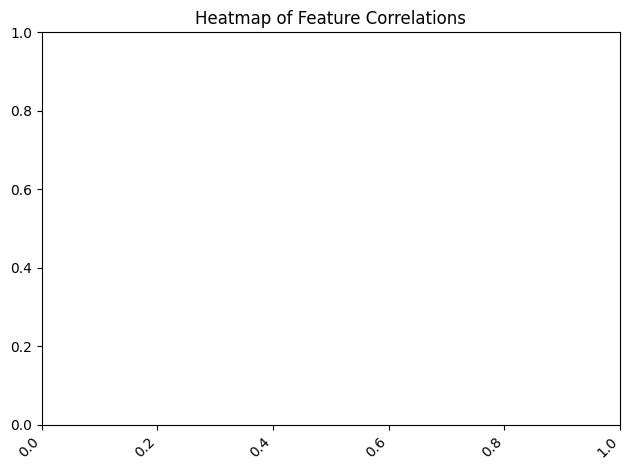

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

##❓YOUR CODE HERE

# calculate the correlation matrix

# plot the correlation matrix (using sns.heatmap)
f, ax = plt.subplots(figsize=(40, 42))

# Rotate the tick labels for better readability
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
# Display the plot
plt.title('Heatmap of Feature Correlations')
plt.tight_layout()
plt.show()

## Section 2: PCA

In this section, we're going to visualize the data using PCA (it's generally good practice to visualize your data) and explore feature importances from PCA. PCA identifies orthogonal eigenvectors that represent directions of high variance in the dataset, using the covariance matrix. This matrix assumes our features are all centered on 0, so we will center and re-scale our features before doing PCA.

Each principal component (eigenvector) is a linear combination of the original features, and the coefficients of these combinations are known as loadings. By examining the loadings, one can identify which original features contribute most to the variance captured by each principal component. Features with high loadings on the first few principal components are usually considered more important, as they contribute significantly to the data's structure, or at least its variance.

When features are highly correlated, PCA tends to capture the variance of these correlated features in fewer principal components. This means that the first few principal components will explain a larger portion of the total variance, as they capture the common variance shared by the correlated features.



❓2.1 Write code below to standardize and scale your data, then do PCA. Visualize the first 3 principal components as an `sns.pairplot`. Label the axes on your pairplot as the percentage variation explained by that principal component. Be sure to adjust `alpha` to avoid overplotting and add a title to your plot.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

##❓YOUR CODE HERE

# standardize the features

# do PCA

# make a df for the PCA results

# get explained variance

## plotting

Looking at the loadings on your principal components, especially components that explain substantial amounts of the variation in your dataset, can be helpful in identifying highly variable features, though these features may also be highly correlated.


❓2.2 Print the top 10 loadings on the first principal component, sorting by absolute value.

In [ ]:
##❓YOUR CODE HERE

# get the loadings

# sort and display the loadings


## Section 3: Regularized Multiple Linear Regression - the LASSO

Unlike Ridge regression or simple multiple linear regression, L1 regularization (the LASSO) can set coefficients of features to 0, effectively selecting a subset of features as "important" for the model.

❓3.1 Use the start of the code below to build a simple linear regression model to predict the output, using L1 regularization (LASSO). How many coefficients does this model set equal to 0? Print the top 10 coefficients (top by absolute value). A test-train split has been established for you. Initialize the LASSO model with `alpha=0.1, random_state=42`.

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split, cross_val_score


# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=12)

##❓YOUR CODE HERE

# Initialize the Lasso model

# fit the model

# Get the coefficients and their corresponding feature names

# sort and display the top coefficients with their feature names

# Print the top 10 features with the largest coefficients


How exciting! Our LASSO discarded a lot of features that it didn't find to be important. It could be that hemotoxicity is a function of just a few molecular features! Before we can conclude that, we should check to see if this model is actually a good fit for the data.

❓3.2 Does this model fit the data well? Make predictions on the test set and calculate the coefficient of determination ($R^2$) between the test predictions and test data. (1 sentence answer). Should you use this model to interpret feature importances? (1 additional sentence)
> *We'll revisit the LASSO to run cross-validation and compare to some decision trees later. This is just a first-pass check on one test data set.*

In [ ]:
##❓YOUR CODE HERE
# Predict on the test set using the fitted model


# Calculate the R^2 value and print
# r2 =
# example of nice printing:)
# print(f"R^2 value of the LASSO model on test data: {r2:.4f}")

✅Answer:

## Section 4: Decision Trees

❓4.1 Write code below to build and evaluate a simple decision tree on all the data, using 5-fold cross-validation. Use `random_state = 12` to seed the Decision tree. Print the RMSE plus or minus its standard error (not standard deviation) from the cross-validation.

In [ ]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import mean_squared_error

##❓YOUR CODE HERE

# Initialize and train the decision tree regressor using 5-fold cross-validation


# run cv on the full model

# print RMSE (nice printing example)
# print(f"Cross-validated RMSE (full model): {cv_rmse.mean()} ± {cv_rmse.std()/np.sqrt(5)}")

If we try to visualize this model (using the code block below, which assumes your scaled dataframe is called `X_scaled` and refits the model to the entire dataset), you'll see that the very large number of features has made this model difficult to interpret, even if the tree organizes more important features to the top. (This is not supposed to be a readable figure, it is here to demonstrate the complexity of the tree growth from these data).

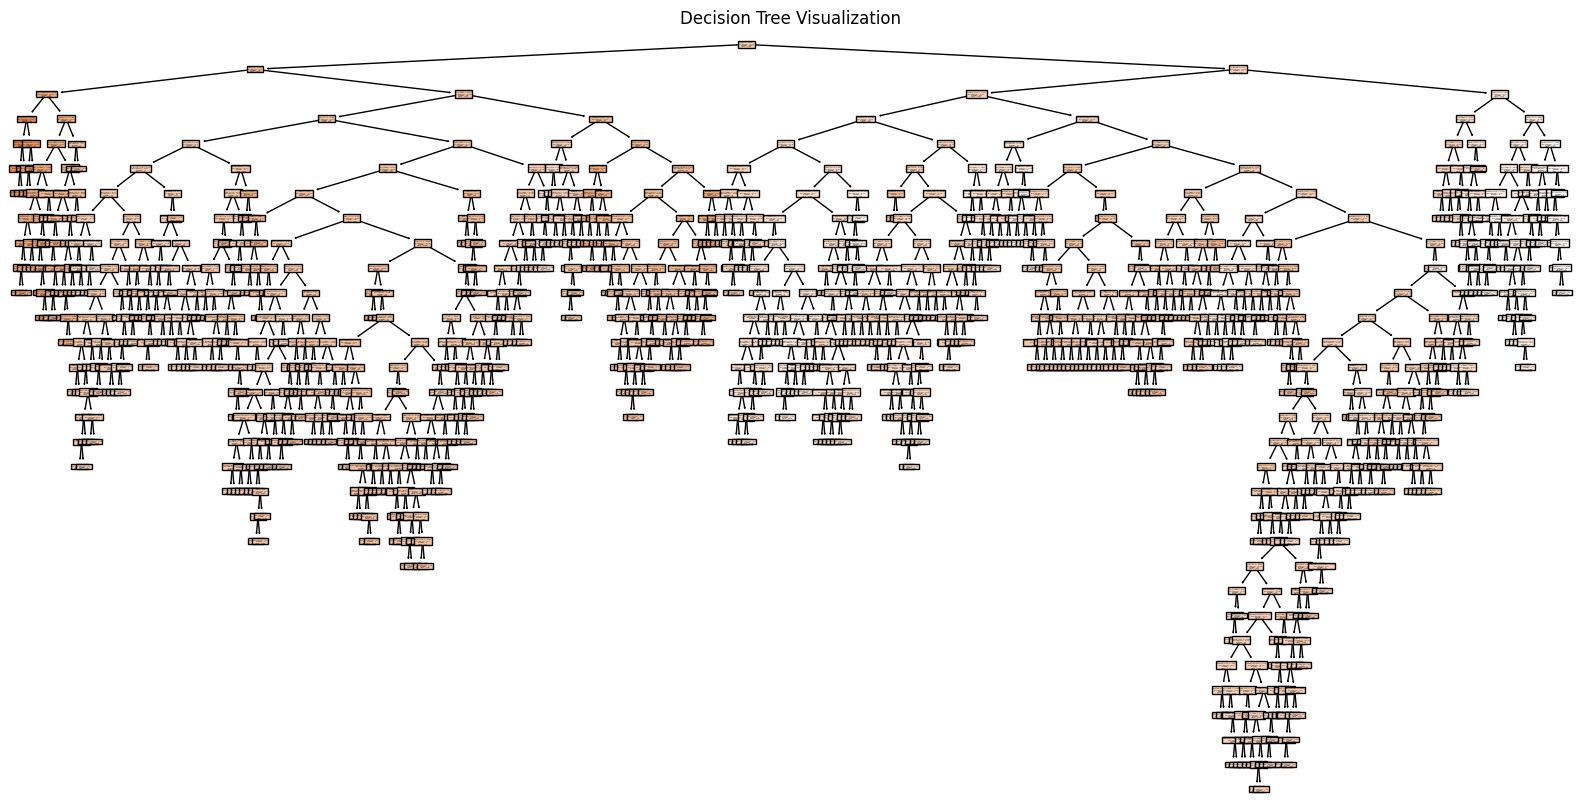

In [ ]:
# Train the model on the entire dataset
model.fit(X_scaled, y)

# Visualize the decision tree
plt.figure(figsize=(20, 10))
plot_tree(model, feature_names=X.columns, filled=True)
plt.title("Decision Tree Visualization")
plt.show()

❓4.2 Build a second model, this time with all the features but a reduced depth (use `random_state=12, max_depth = 4`). Report the 5-fold cross-validation RMSE, plus or minus its standard error (not standard deviation). *Start naming your models and RMSEs different things, you're going to have to compare them later.*

In [ ]:
##❓YOUR CODE HERE
# Build a model with a limited depth

# cv on the shallow model, using all the data


Note that this new model only uses some of the features because it is depth-limited. This limitation also makes it much easier to visualize! The codeblock below will run and show your decision tree, provided you've called your new model `model_shallow`.

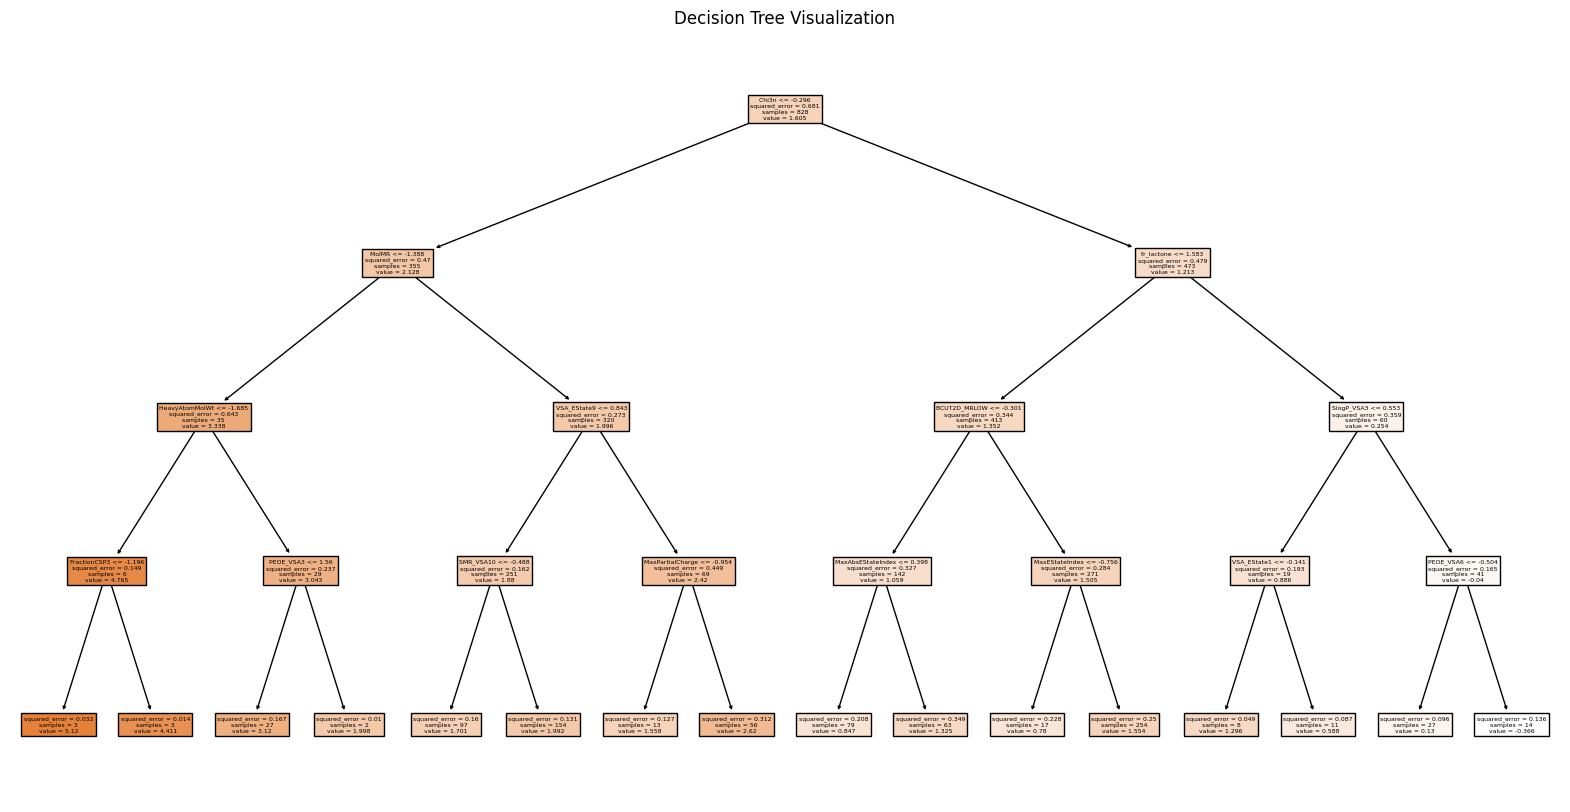

In [ ]:
# fit the model on the entire dataset (not cross-validation)
model_shallow.fit(X_scaled, y)

# Visualize the decision tree
plt.figure(figsize=(20, 10))
plot_tree(model_shallow, feature_names=X.columns, filled=True)
plt.title("Decision Tree Visualization")
plt.show()

❓4.3 Why does this second model have a lower cross-validation error? (1-sentence answer) Is this depth-limited tree an example of pruning or early stopping?

✅ Answer:

❓4.4 Build a model with a reduced input feature set, using a Variance Threshold of 0.2 to remove low-variance features. Continue limiting the depth of the tree with `random_state=12, max_depth = 4`. Report the 5-fold cross-validation RMSE, plus or minus its standard error (not standard deviation).
> you can use `selected_features = selector.get_support(indices=True)` to get the feature names of the of the data left after selection.

In [ ]:
##❓YOUR CODE HERE
# Build a second model with low-variance features removed


# Initialize and train the reduced model using 5-fold cross-validation

# cv on the reduced model, using all the data


❓4.5 Use 5-fold cross-validation to compute RMSE and evaluate your LASSO model from earlier. Report the 5-fold cross-validation RMSE, plus or minus its standard error (not standard deviation).

In [ ]:
##❓YOUR CODE HERE
# cross-validation, lasso is already defined above


Cross-validated RMSE (LASSO model): 0.7146578384714735 ± 0.10837876059856173


❓4.6 Plot and compare all 4 models' RMSE with error bars (standard error).
> Your models should be the "Full Decision Tree", "Shallow Decision Tree", "Filtered Shallow Decision Tree" and "LASSO"

In [ ]:
##❓YOUR CODE HERE
# Compare the models' RMSEs with error bars

plt.ylabel('Root Mean Squared Error (RMSE)')
plt.title('Comparison of RMSE between Models')
plt.xticks(rotation=45, ha='right')
plt.show()

❓4.7 Was there a significant change in model performance when you compare using all the data to using just a subset of the data (with the same `max_depth = 4` parameter)? Why or why not? *Hint: Both of these limited-depth trees have used "early stopping" to avoid overfitting. Generally, what variables are these trees using to make decisions?*

> *You should not have to do a statistical test to see whether or not there was a significant difference between these two conditions, it should be obvious from looking at your plot.*

✅Answer:

❓4.8 Were any of these good models? Since RMSE has the same units as the response variable (like standard deviation does), compare the RMSE to the scale of the data by making a histogram and/or boxplot of the response variable to understand if RMSE around 0.7 is reasonable, given the scale of the data. *Feel free to explicitly calculate standard deviation, IQR, or other summary metrics that help you understand this data distribution. A plot of the distribution of the response variable is a much more complete qualitative picture than just summary metrics, which is why it's provided here as a suggestion as a place to start.*

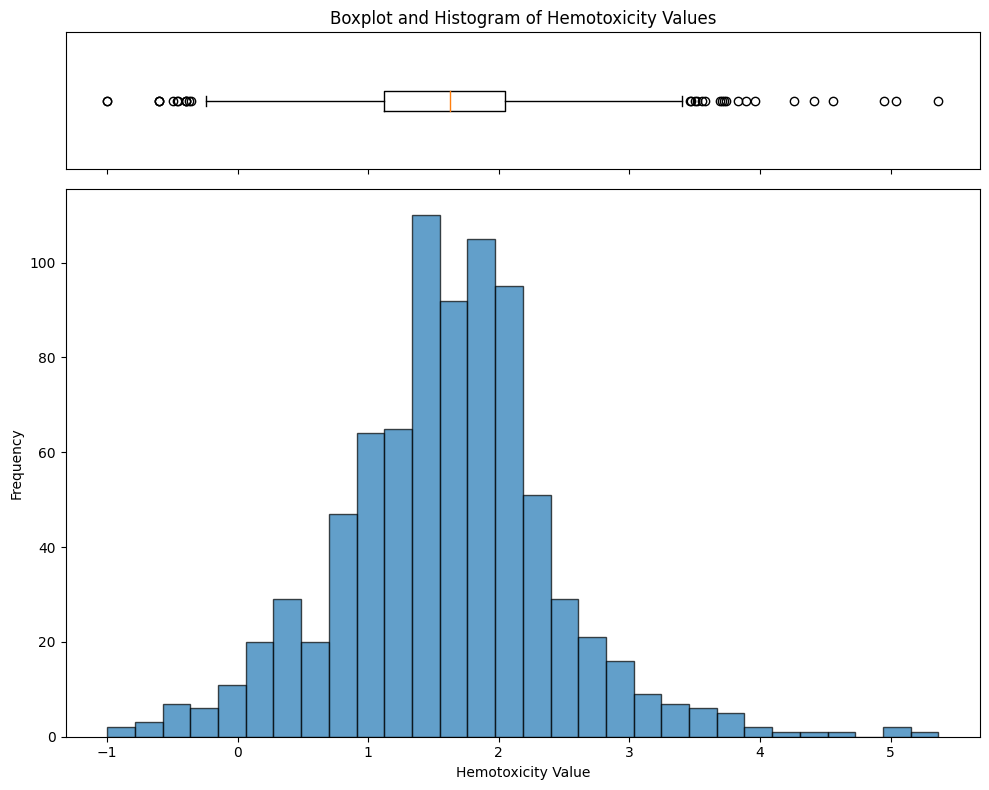

In [ ]:
##❓YOUR CODE HERE

# output from TAs left here so you can see what the scale of hemotoxicity values should be
# and what sort of graph we're asking for here
# you don't have to exactly recreate this plot! Feel free to add or remove elements as you like
# fig, (ax_box, ax_hist) = plt.subplots(nrows=2, sharex=True,
#                                      gridspec_kw={"height_ratios": [1, 5]},
#                                      figsize=(10, 8))

✅Answer (~1 sentence):

## Section 5: Math - Node impurities

In the regression case, decision trees can minimize mean squared error between the predicted response value and the true response value. In the classification case, the "error" is slightly more complicated.

We're going to calculate some node impurities by hand! **Please show all your work for this section. Submit typeset or clear handwritten work.**

We're going to look at a toy dataset of apples and bananas, each of which has an associated color and weight. In this scenario, we're trying to predict the type of fruit based on its properties.

| Weight (g) | Color | Type   |
|------------|-------|--------|
| 155        | green   | Apple  |
| 132        | red     | Apple  |
| 175        | yellow  | Banana |
| 152        | green   | Banana |
| 141        | *yellow*  | Apple  |
| 170        | yellow  | Banana |

❓5.1 Calculate the gini index (also called impurity) of the root node (all the samples).

✅Answer:

❓5.2 Split the fruits by whether or not their weight is greater than 150 g and calculate the Gini index for both resulting nodes.

✅Answer:

Node 1 (<=150 g):

Node 2 (>150 g):

❓5.3 Split the fruits by whether or not they're yellow and calculate the Gini index for both resulting nodes.

✅Answer:
> Node 1 (yellow):

> Node 2 (non-yellow):

❓5.4 Which split results in the greatest weighted average decrease in impurity?

✅Answer: